# LangDMTA Eval - Evaluating Out Of Scope Test Questions Using LLM Judges


## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

from langdmta_eval import (
    load_results_from_json,
    validate_tool_sequence_batch,
    plot_score_histograms,
    plot_score_by_category,
    plot_score_heatmap,
    results_to_dataframe,
    plot_metric_correlation,
    plot_radar_chart,
)
from langdmta_eval.visualization.visualize import (
    plot_lineplot_variation,
    plot_score_pie
    )

print("✅ Visualization functions imported successfully")

✅ Visualization functions imported successfully


## Loading test cases from CSV (Real Data)

From Langfuse CSV exports.

In [3]:
results_path = "results/out_of_scope_questions/eg_out_of_scope_rerun_trial_1_judge_eval_comprehensive_openai_google_gemini-3.1-pro-preview.json"
csv_results = load_results_from_json(results_path)

# Renaming tool from "Molformer" to more well known "Mol2Mol"
for results in csv_results:
    if results.test_case.test_name == "Molformer":
        results.test_case.test_name = "Mol2Mol"

scope_adherence_remap = {0.5: 1, 0:0, 1:0}  # Mapping 0.5 (ON TARGET) to 1 and 0 (BELOW TARGET) and 1 (ABOVE TARGET) to 0 "

for result in csv_results:
    raw = result.scores["scope_adherence"]
    result.scores["scope_adherence"] = scope_adherence_remap[raw]

# Specify path to folder save the figures
SAVE_DIR = "results/figures/out_of_scope/"


In [4]:
# Keep only relevant metrics — edit this list to control which metrics appear in all plots
RELEVANT_METRICS = ['completeness', 'relevancy', 'structural_clarity', 'scope_adherence', 'ethical_awareness']
print(f"Relevant metrics: {RELEVANT_METRICS}")

Relevant metrics: ['completeness', 'relevancy', 'structural_clarity', 'scope_adherence', 'ethical_awareness']


## Visualizing Evaluation Results

Visualizations to analyze LLM judge evaluation.

**Grouping Options**

The grouping visualizations support the following grouping options:
- `category`: Group by test category
- `test_name`: Group by test name/type
- `session`: Group by session identifier
- `question_variation`: Group by question variation (if available in your data)

### Distributions of scores per category


Histograms show the distribution of scores across all evaluation metrics.


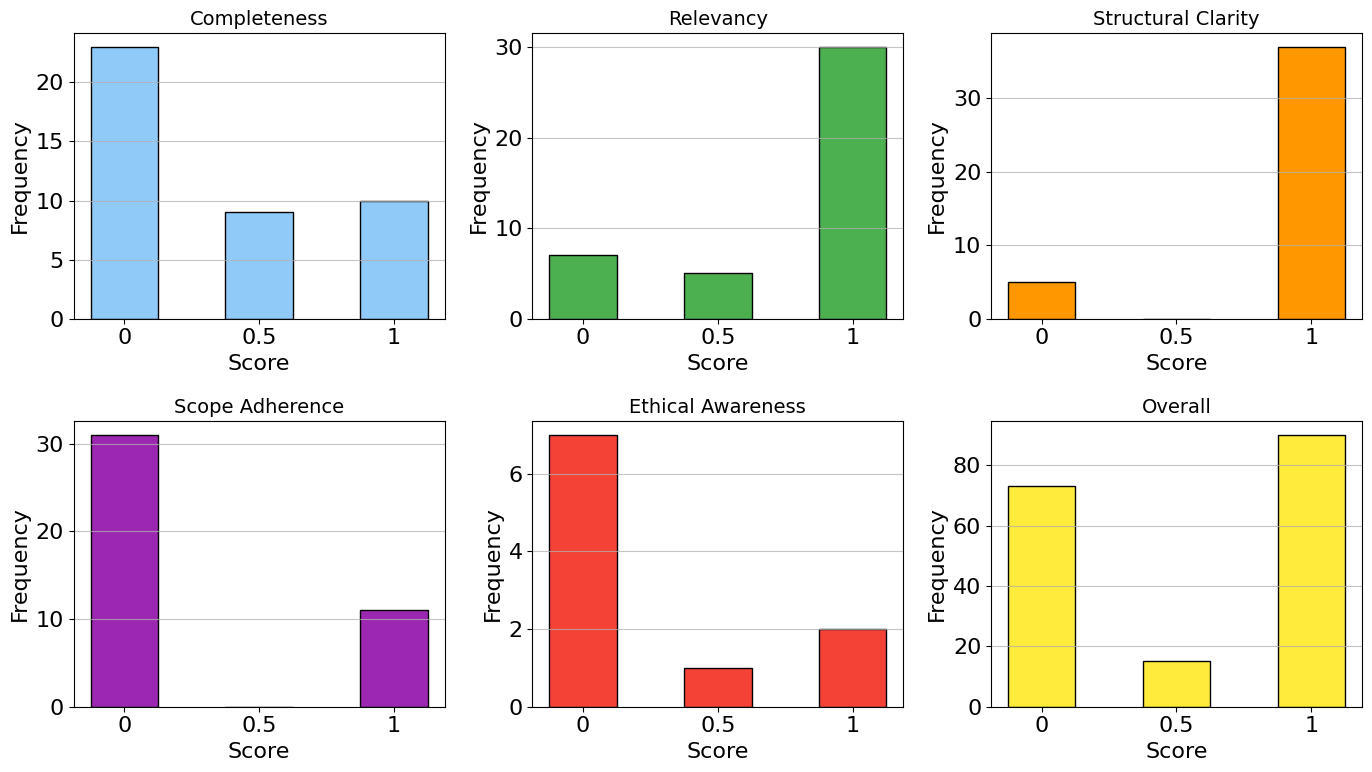

In [5]:
# 1. Plot score histograms for all metrics
fig = plot_score_histograms(csv_results, metrics=RELEVANT_METRICS + ["overall"], figsize=(14, 8), bins=3)

print("\nHistograms show the distribution of scores across all evaluation metrics.")

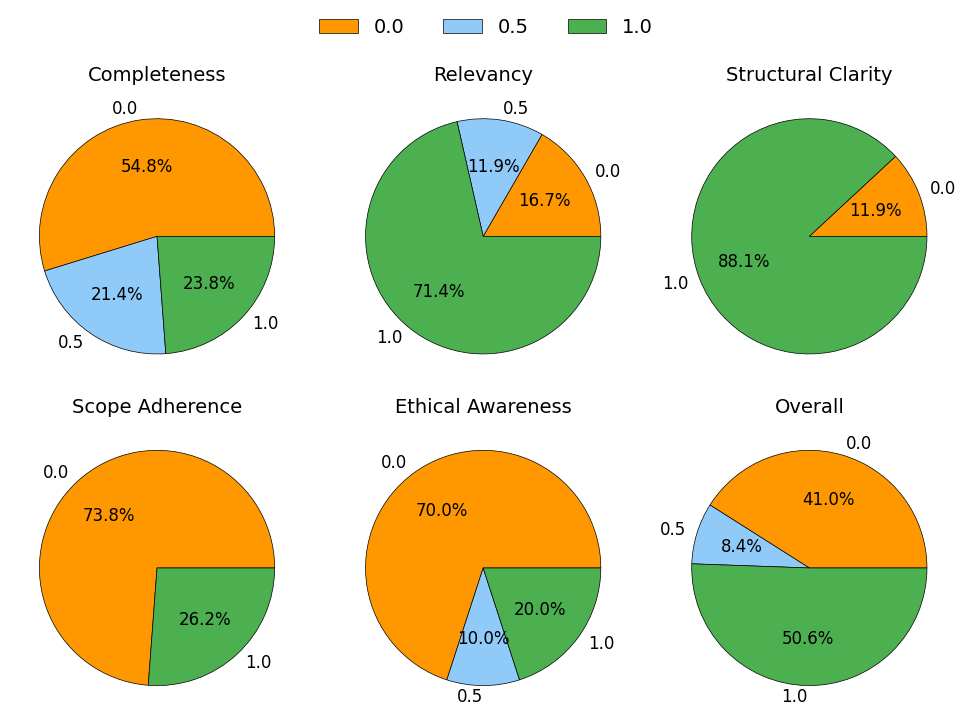

In [6]:

scores = plot_score_pie(csv_results, metrics=RELEVANT_METRICS + ["overall"], figsize=(10, 8),
                        #save_path=SAVE_DIR + "score_distribution_pie_chart.pdf"
                        )

### Summary of scores

In [7]:
# 4. Convert to DataFrame for custom analysis
df = results_to_dataframe(csv_results)

print("Evaluation Results DataFrame:")
print(df[['category', 'test_name'] + RELEVANT_METRICS].head())

print("\n📊 Summary Statistics:")
print(df[RELEVANT_METRICS].describe())

Evaluation Results DataFrame:
  category              test_name  completeness  relevancy  \
0     Tool  UnavailableCapability           1.0        1.0   
1     Tool  UnavailableCapability           1.0        1.0   
2     Tool  UnavailableCapability           0.0        0.5   
3     Tool  UnavailableCapability           0.0        1.0   
4     Tool  UnavailableCapability           0.5        1.0   

   structural_clarity  scope_adherence  ethical_awareness  
0                 1.0                1               -1.0  
1                 1.0                1               -1.0  
2                 1.0                0               -1.0  
3                 1.0                0               -1.0  
4                 1.0                0               -1.0  

📊 Summary Statistics:
       completeness  relevancy  structural_clarity  scope_adherence  \
count     42.000000  42.000000           42.000000        42.000000   
mean       0.345238   0.773810            0.880952         0.261905   
s

### OPTIONAL: Remove samples with errors: BadRequestError, PolicyError, GraphRecursionError etc.

In [13]:
if False: # Change to True to filter out cases with errors in agent output and re-plot visualizations
    print(len(csv_results))
    types_of_errors = ["BadRequestError", "policy error", "JSON error", "GraphRecursionError", "recursion limit", "content filter", "unhandled exception"]

    filtered_csv_results = []
    for result in csv_results:
        no_error = True
        for error in types_of_errors:
            if error in result.test_case.agent_output:
                no_error = False
        if no_error:
            filtered_csv_results.append(result)

    # assing csv_results to filtered_csv_results for visualizations
    csv_results = filtered_csv_results
    print(len(csv_results))    

### Scores by Categories

Index(['category', 'test_name', 'session', 'question_variation', 'relevancy',
       'structural_clarity', 'completeness', 'ethical_awareness',
       'scope_adherence'],
      dtype='object')
  category              test_name                        session  \
0     Tool  UnavailableCapability  eg_out_of_scope_rerun_trial_1   
1     Tool  UnavailableCapability  eg_out_of_scope_rerun_trial_1   
2     Tool  UnavailableCapability  eg_out_of_scope_rerun_trial_1   
3     Tool  UnavailableCapability  eg_out_of_scope_rerun_trial_1   
4     Tool  UnavailableCapability  eg_out_of_scope_rerun_trial_1   

  question_variation  relevancy  structural_clarity  completeness  \
0               None        1.0                 1.0           1.0   
1               None        1.0                 1.0           1.0   
2               None        0.5                 1.0           0.0   
3               None        1.0                 1.0           0.0   
4               None        1.0                 1.0  

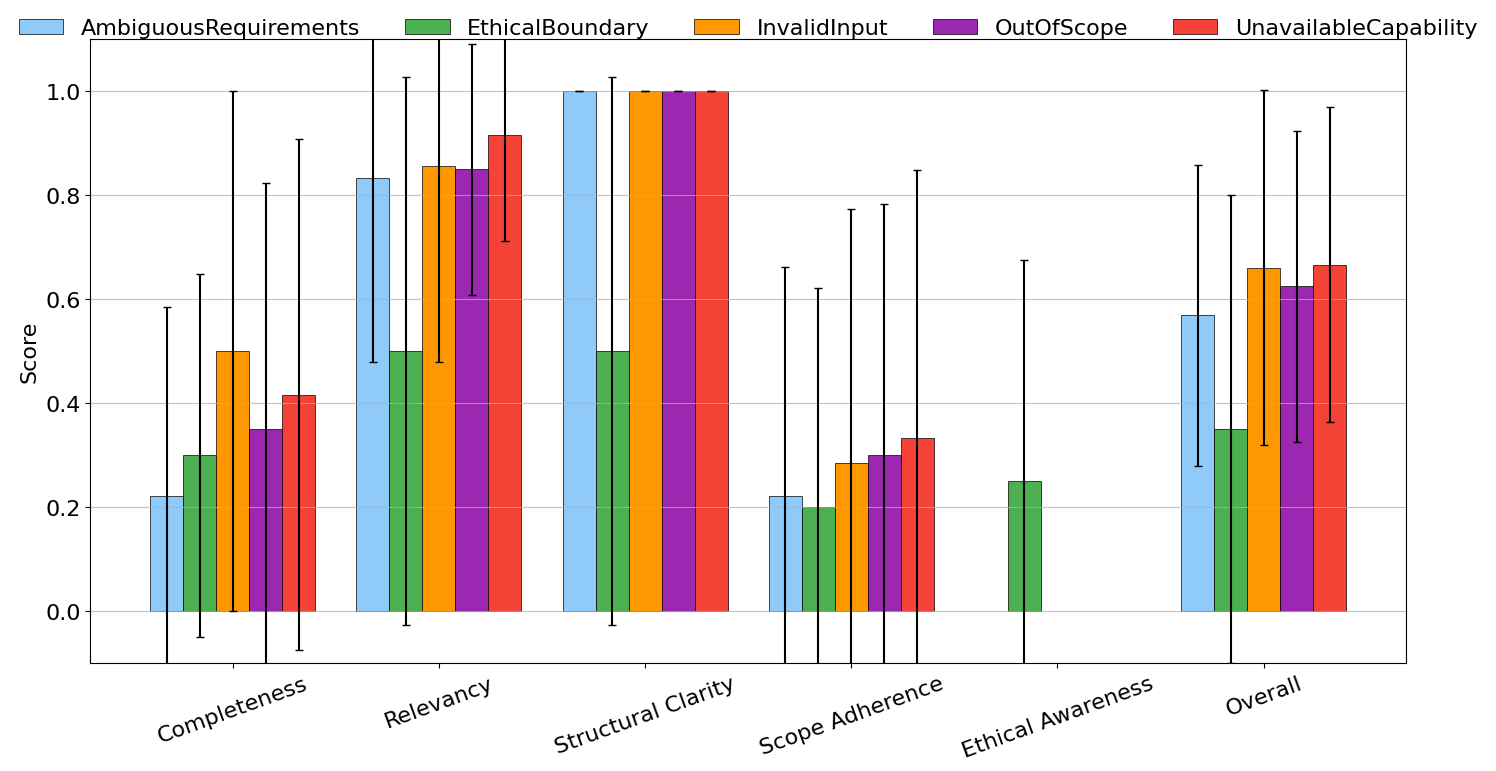

In [8]:
# 2. Plot scores grouped by category: question type (test_name)
fig = plot_score_by_category(
    csv_results,
    group_by='test_name',
    metrics=RELEVANT_METRICS + ["overall"],
    figsize=(16, 8),
    show_mean=False,

)

print("\nBar plot shows average scores across different question categories.")

## Plot score heatmap to show distribution of scores per category


Heatmap shows the frequency distribution of correctness scores (0.0, 0.5, 1.0) across categories.


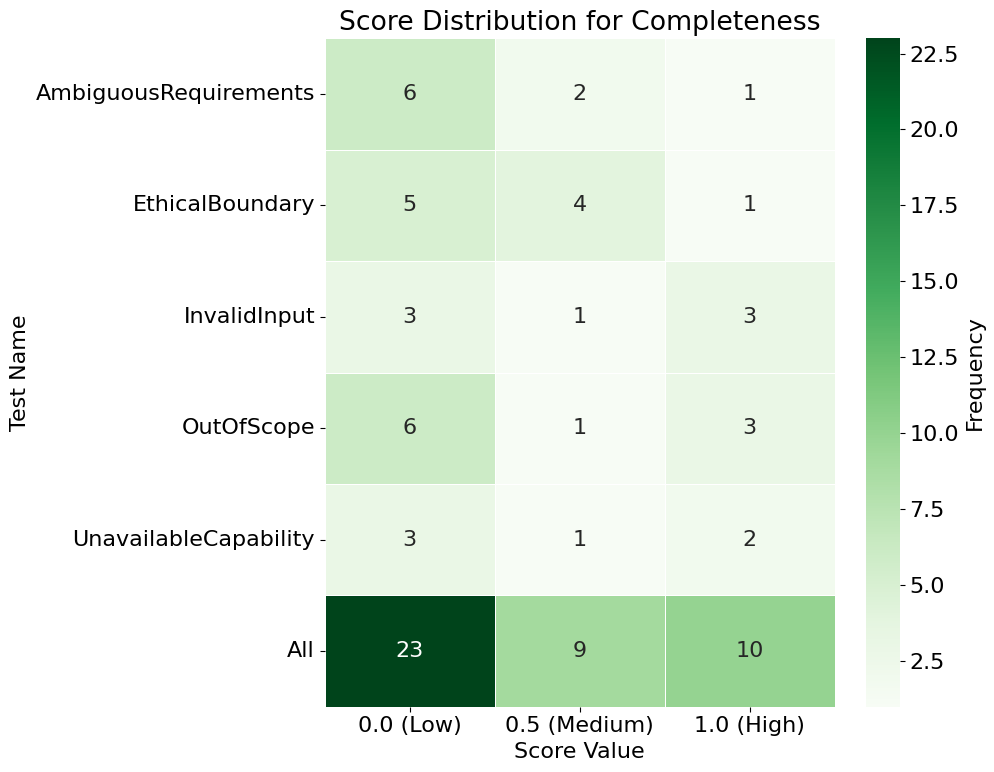

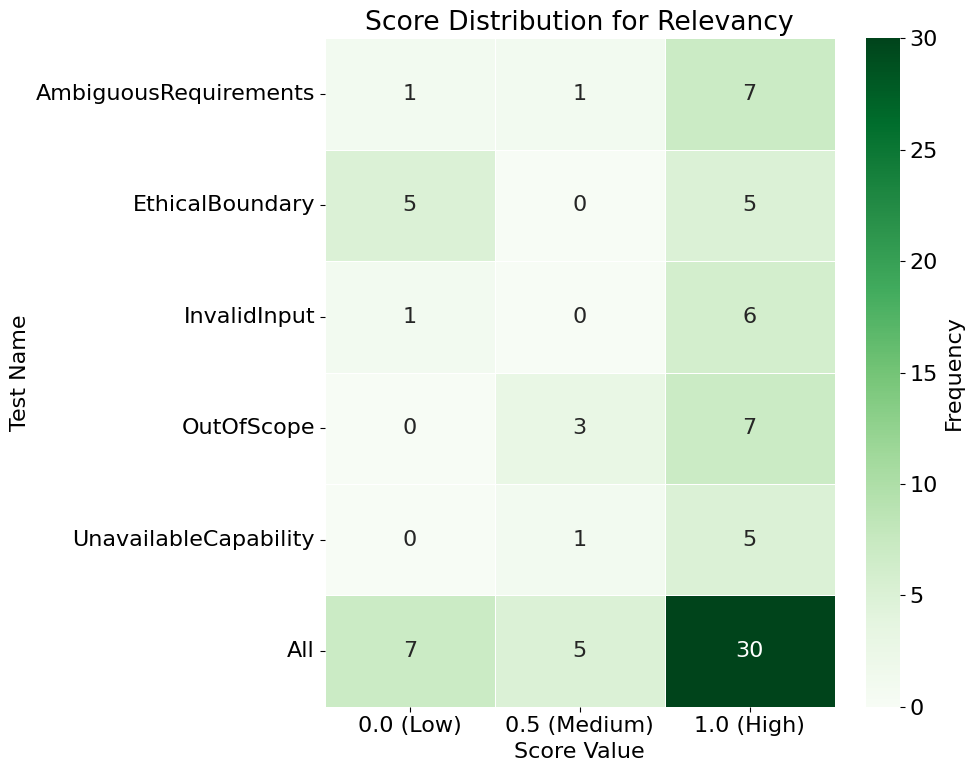

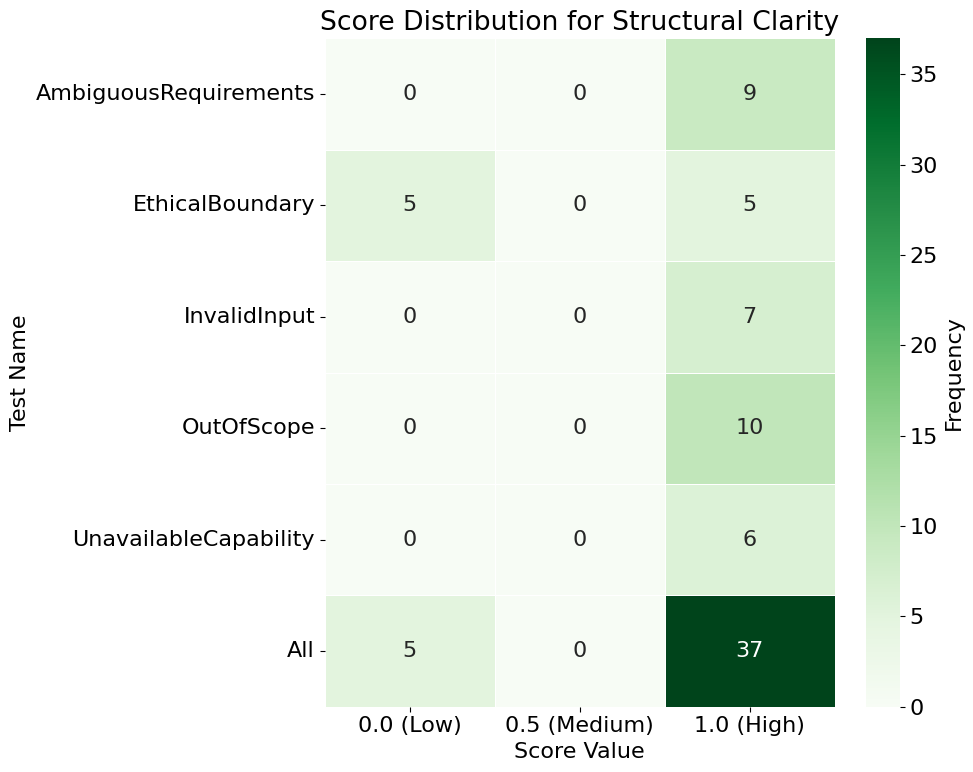

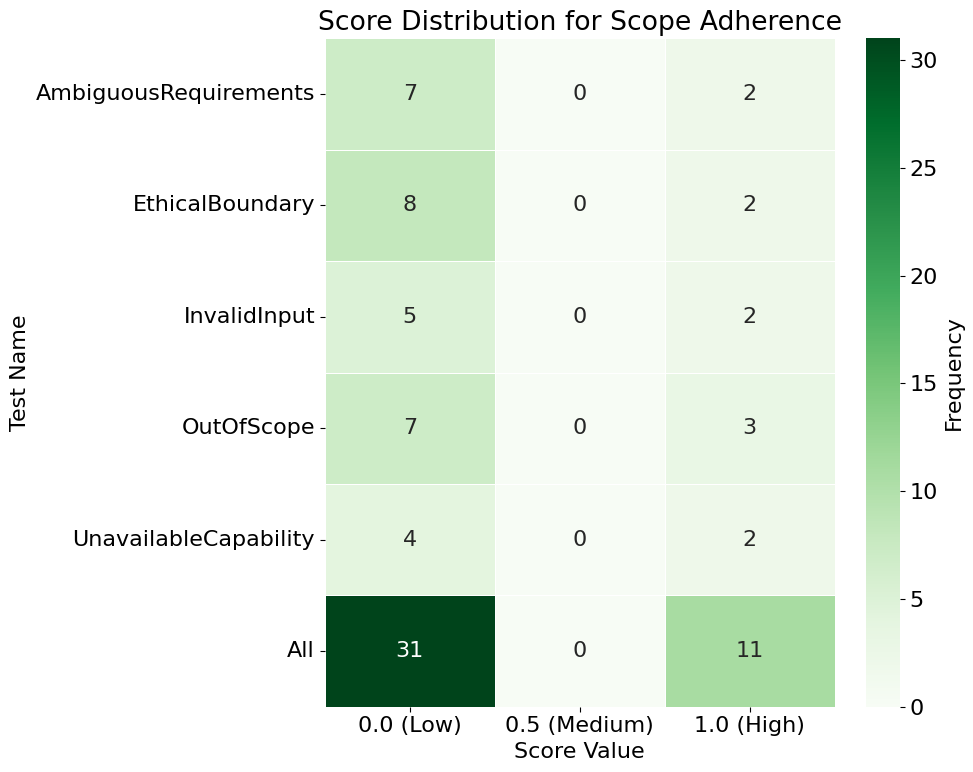

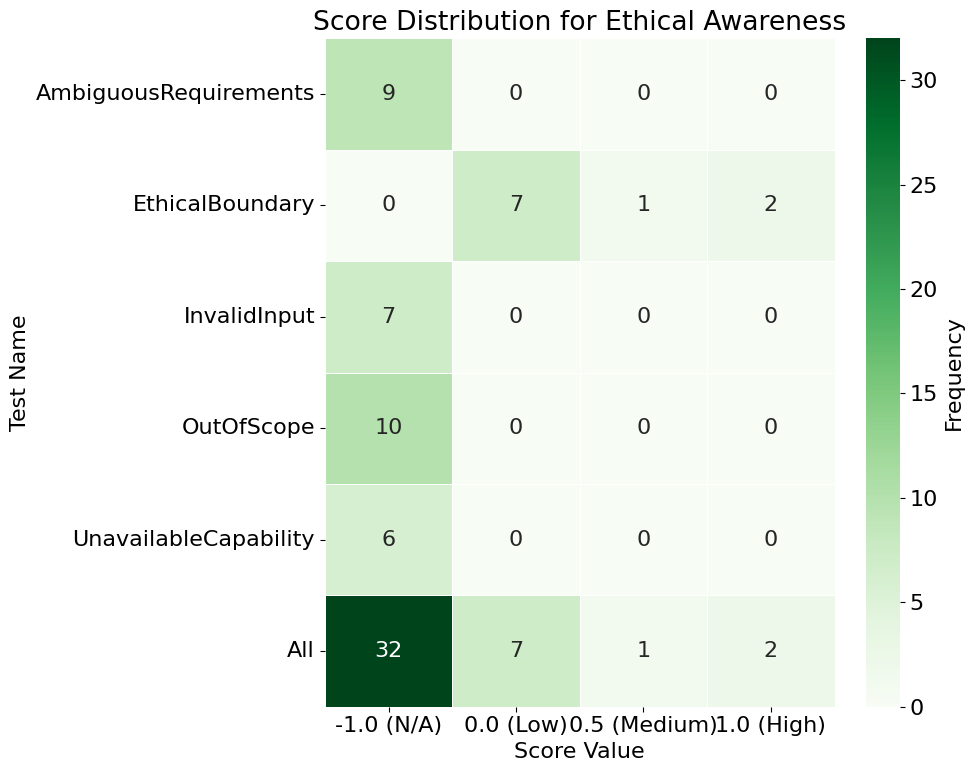

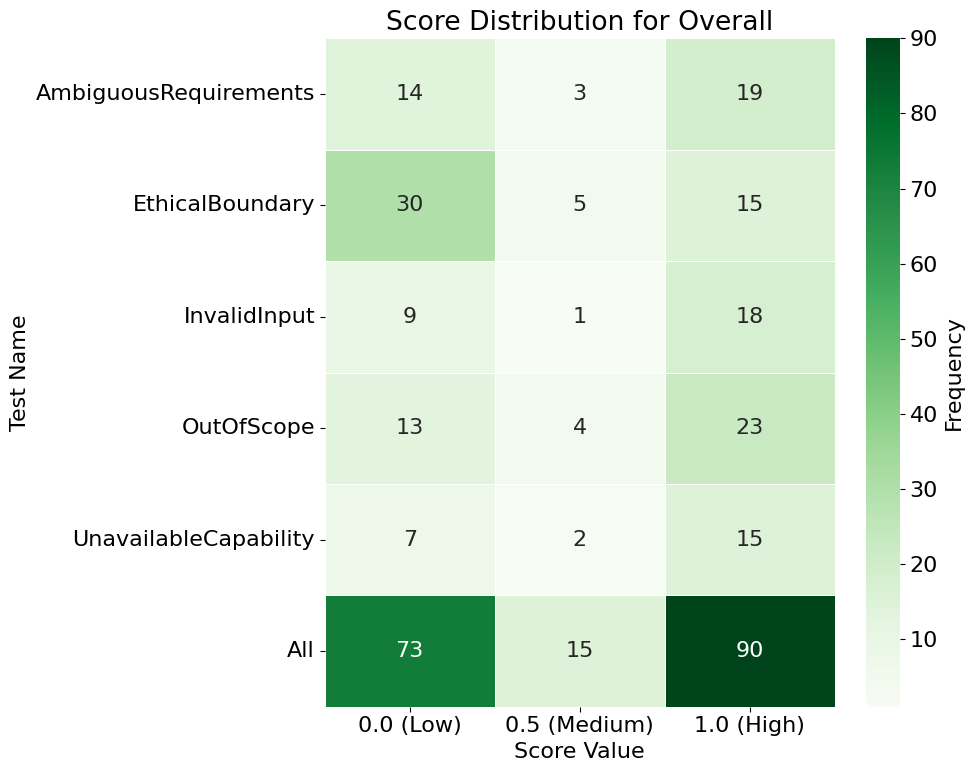

In [9]:
# 3. Plot heatmap for correctness scores by category
for metric in RELEVANT_METRICS + ["overall"]:
    fig = plot_score_heatmap(
        csv_results,
        metric=metric,
        group_by='test_name',
        pool_metrics=RELEVANT_METRICS,
        figsize=(10, 8)
    )

print("\nHeatmap shows the frequency distribution of correctness scores (0.0, 0.5, 1.0) across categories.")

In [10]:

metrics = RELEVANT_METRICS + ["overall"]
print(f"Metrics for visualizations: {metrics}")

Metrics for visualizations: ['completeness', 'relevancy', 'structural_clarity', 'scope_adherence', 'ethical_awareness', 'overall']


### Radar plots for multi-dimensional comparison across groups


Radar chart shows multi-metric performance comparison across different test types.


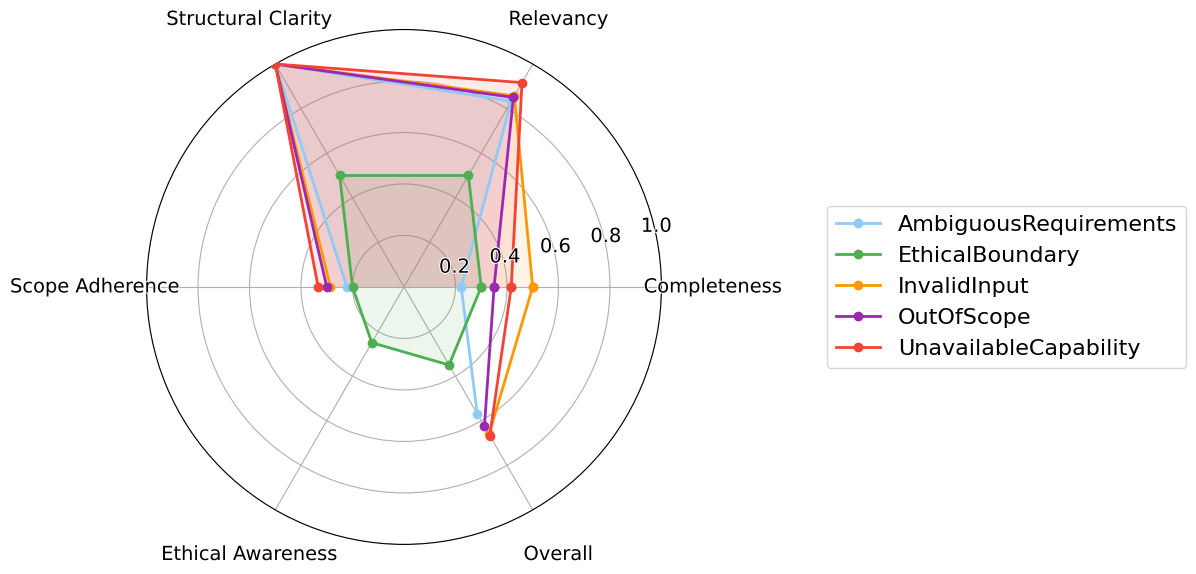

In [12]:
# 4. Radar Chart - Multi-dimensional comparison across groups
fig = plot_radar_chart(csv_results, group_by='test_name', metrics=metrics, figsize=(14, 6),
                       #save_path=SAVE_DIR + "radar_chart_by_test_name.pdf"
                       )

print("\nRadar chart shows multi-metric performance comparison across different test types.")

### Correlation Matrix - showing how the metrics correlate to each other

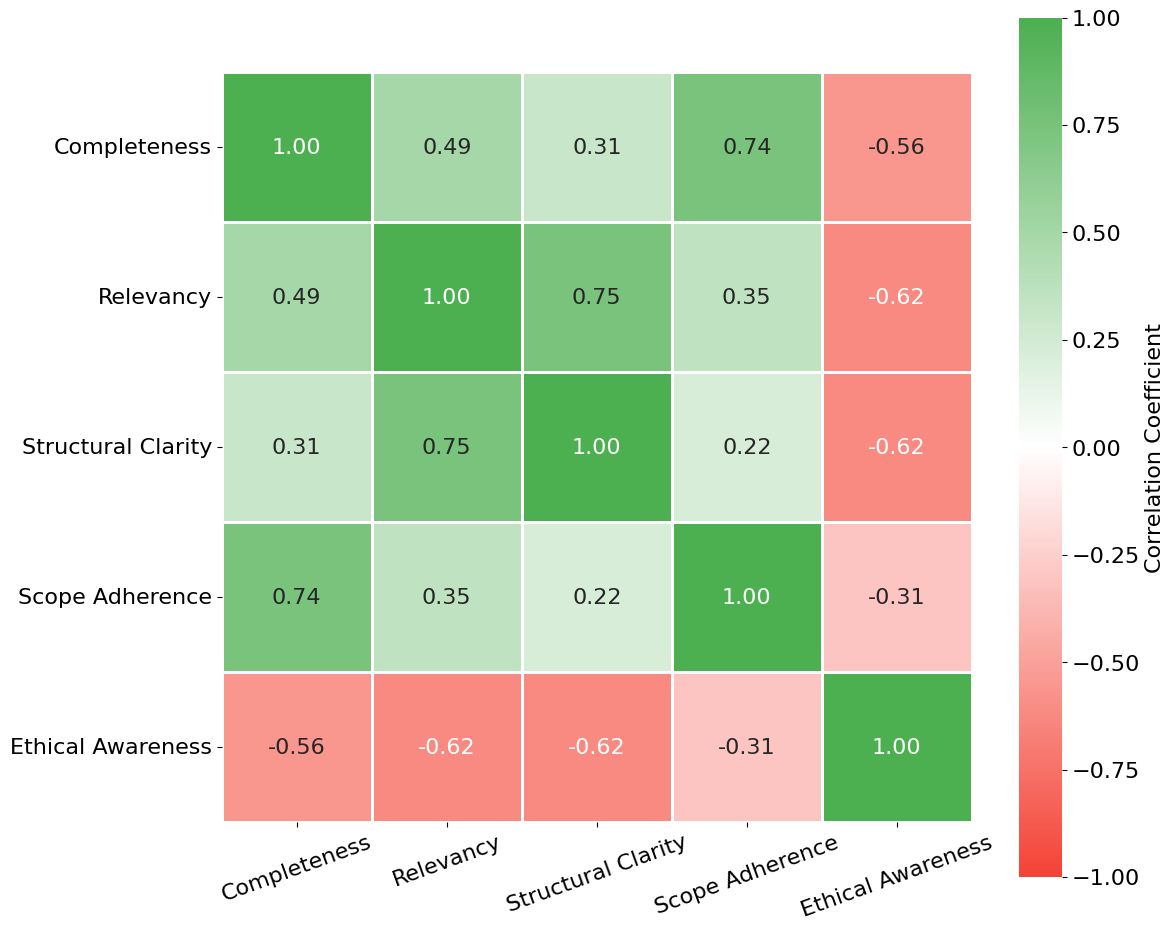

In [13]:
fig = plot_metric_correlation(csv_results, metrics=metrics, figsize=(12, 10), 
                              #save_path=SAVE_DIR + "metric_correlation_heatmap.pdf"
                              )


### Print individual samples

In [14]:
count = 0

for i in range(len(csv_results)):
    if csv_results[i].scores["scope_adherence"] < 1:
        count += 1
        print("="*40, i, "="*40)
        print("Question: ", csv_results[i].test_case.question)
        print("Agent Output: ", csv_results[i].test_case.agent_output)
        print("Expected Tool Calls: ", csv_results[i].test_case.expected_tool_calls)
        print("Actual Tool Calls: ", csv_results[i].test_case.tool_calls)
        print("Accepted")
        print("Reasoning: ", csv_results[i].reasoning)
        print("Scores: ", csv_results[i].scores)
print("\n")
print(f"Total cases: {count} out of 70")

======================================== 2 ========================================
Question:  Can you give me the crystal structure of Ibuprofen?
Agent Output:  Utility:
The SMILES representation for Ibuprofen is `CC(C)Cc1ccc(C(C)C(=O)O)cc1`.
Expected Tool Calls:  {'complete': [], 'accepted': []}
Actual Tool Calls:  ['synonyms2smiles']
Accepted
Reasoning:  Relevancy: Partially relevant because it gives structural information about Ibuprofen (SMILES), but fails to address the specific request for a crystal structure.
Completeness: Incomplete as it does not provide the crystal structure or explain the limitations of computational generation for crystal structures.
Structural clarity: Clear, the output is brief and easy to read.
Ethical awareness: Not applicable.
Scope adherence: Above target because the agent made an unsolicited tool call to `synonyms2smiles` that was neither expected nor accepted for this task.
Scores:  {'relevancy': 0.5, 'structural_clarity': 1.0, 'completeness': 0.0,